# Tercer Semesre

Creación de modelo ahora basado en agentes en el que cada sitio $V[i,j]$ tiene un costo de  que ya están pagando esa renta divididos en 3 estratos. El sitio $i,j$ tiene una población $P_k[i,j](t)$ de individuos de estrato $k$ al tiempo $t$.

Una condición que podría cumplirse es que

$$
\sum_{i,j}P_1 [i,j] (t) > \sum_{i,j}P_2[i,j] (t) > \sum_{i,j}P_3 [i,j] (t)
$$

Es decir, que en la población total de todas los sitios hay más personas de los estratos bajos que de los altos.

Cada estrato $j$ tiene un salario $S_j$ que cumple con

$$
S_1 < S_2 < S_3
$$

(por lo pronto 10, 20, 30 correspondiente a cada estrato). Donde $k \in \{1,2,3\}$ son los estratos.

Capacidad de carga:  
$\forall (i,j, t).  \,\,  P_1 [i,j] (t) + P_2[i,j] (t) + P_3 [i,j] (t) \leq q_{i,j}$  es la cantidad más grande de personas que puede vivir en la sitio $i,j$

C.I.: Para $t=0$ y para $\forall[i,j]$  se  cumple  que

$$[i,j] = \begin{cases}
P_1 [i,j] (t) + P_2[i,j] (t) + P_3 [i,j] (t) = q  &\text{ si [i,j] no está en la periferia} \\
0 & \text{si sí está en la periferia}
\end{cases}
$$


También se debe cumplir en todo momento que
$$
\sum_{ij} P_k^t [i,j] = a_k
$$
Es decir, no hay movimiento entre los estratos.

El procedimiento de actualización es el siguiente
Determinamos a dos grupos de pobladores $C_k$ e $I_k$ para cada estrato, estos dos grupos se definen a continuación.
* $C_k$ es el grupo de colonos cuyo ingreso es mayor a la renta donde viven.  
* $I_k$ es el grupo de colonos que viven en un lugar que no pueden pagar, es decir los cuales su salario $s_k < V_k[i,j]$

Pasos:

1. Una proporción $\alpha$ de los Inconfromes $I_k$ abandona el lugar donde están, y se queda "flotando", es decir sin lugar alguno.  Esto hace que algunas sitios tengan menor población, momentáneamente. Llamemos $F$ a este conjunto temporal de gente flotando.

2. Una proporción $\beta$ de los conformes $C_k$, se mueve a algún lugar que esté desocupado. Es decir, eligen un lugar $i,j$ para el cual $P_1 [i,j] + P_2[i,j] + P_3 [i,j]  < q_{i,j}$.  Esto podría dejar desocupados otros lugares momentaneamente.  Si todos los lugares que uno de los conformes puede pagar están ocupados, se queda en el lugar donde está actualmente.

3. Los agentes que están en $F$ van, **en orden de su ingreso**, intentando ocupar una localidad  $i,j$ que
 *  tenga espacio ($P_1 [i,j] + P_2[i,j] + P_3 [i,j]  < q_{i,j}$), y
 * que pueda pagar $s_k < V[i,j]$ donde $k$ es el estrato del agente.


Despúes de estos tres pasos se puede actualizar el valor de la tierra con:

$$ V[i,j](t+1) =  V[i,j](t) + G(.. ) $$


(Otra opción sería algo como....

$$ V[i,j](t+1) =  S_1 P_1[i,j](t) + S_2 P_2[i,j](t) + S_3 P_3[i,j](t) + G(.. ) $$

)


________________________

 a donde sea que le alcance con su $s_k$, es una proporción $\alpha \sum_{ij} P_k$ al sitio $V_k [i,j]$.
Mientras que el grupo de inconformes $I_k$ son todos aquellos para
$$
\begin{cases}
C_k(t) = \alpha \sum_{ij} P_k(t-1) \\
V[i,j] > S_k \implies I_k (t) = \sum_{ij} P_k^t [i,j] \\
\end{cases}
$$


1. Una parte de los inconformes se mueve al sitio $[i,j]$

$$\begin{array}
  \ \Delta P_k [i,j] (t) &= \beta I_k (t-1) & \text{si }  V[i,j] \le S_k
\end{array}
$$
1. Los conformes aburrido se mueven a donde deseen
$$\begin{array}
 \ \Delta P_k [i,j] (t) &= \gamma C_{k+1} (t-1) & \text{si }V[i,j] \le S_{k-1}
\end{array}
$$

3.  Los IN


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from numpy import random


In [2]:
class Vecindario(object):

  def __init__(self,
               n     : int,           # tamaño de la matriz
               f     : str,           # tipo de distribucion para V
               Q     : int,           # cantidad total de gente
               P     : list,          # proporciones de cada estrato [P1, P2, P3]
               params: dict,          # parametros de distribucion
               pad   : int = 2,       # valor de padding para periferia
               rng = None):
    """
    n      : dimensión de la malla (nxn)
    f      : función de distribución de probabilidad
    Q      : poblacion de agentes totales por sitio
    P      : proporciones de cada estrato [P1, P2, P3]
    params : diccionario con parámetros de distribución de probabilidad
    pad    : valor de padding para la periferia
    rng    : generador de números aleatorios
    """
    # Condiciones a satisfacer
    assert sum(P)==1, "P debe sumar 1"
    assert P[0] > P[1] > P[2], "P debe estar en orden decreciente"
    assert 2*pad < n, "El padding debe ser menor al tamaño de la matriz"
    assert f in ['gaussian', 'power_law', 'binomial'], "f debe ser gaussian o power_law o binomial"

    self.pad    = pad
    self.params = params
    self.n      = n
    self.Q      = Q      # cantidad total de agentes
    # self.Q      = 0 # funcion para asociar capacidad incial por sitio
    self.rng    = random.default_rng() if rng is None else rng

    # espacio de la renta
    # aquí definimos cuánto vale la renta de los inmuebles en cada
    # celda
    self.f     = f                # cómo va a ser la distribución del ingreso
    self.V     = np.zeros((n,n))  # malla para acomodar el ingreso
    datos      = self._genera_V(f, params)
    self.V[pad:n-pad, pad:n-pad] = datos

    # poblaciones por estrato
    self.P = { (i+1): P[i]*Q for i in range(3)}
    print("Cantidad de agentes por estrato")
    print(self.P)
    # salarios: definimos cuánto puede recibir cada
    # tipo de agente por estrato
    self.C = { f'S{i+1}': 1 / P[i] for i in range(3)} # salario
    print("Salarios por estrato")
    print(self.C)
    # a partir de P y C generar cuánta gente puede
    # habitar el sitio [i,j]

    print("Poblando estratos")
    self.p1, self.p2, self.p3 = self._poblar_estratos()
    # self.iteracion()

  def _genera_V(self,
                f: str,
                params: dict ):
    """
    Se genera la distribución de escalares en V
    f : str tipo de distribución ['gaussian', 'power_law', 'binomial']
    """
    n = self.n
    rng = self.rng

    # interior
    pad = self.pad
    shp  = (n - 2 * pad,
            n - 2 * pad)

    if f == 'gaussian':
      gauss_mean, gauss_std = params['gauss_mean'], params['gauss_std']
      datos = rng.normal(loc=gauss_mean, scale=gauss_std, size=(shp[0], shp[1]))
      datos = np.abs(datos)

    elif f == 'power_law':
       pl_alpha = params['pl_alpha']
       datos = rng.pareto(pl_alpha, size=shp) + 1

    elif f == 'binomial':
      bin_n, bin_p = params['bin_n'], params['bin_p']
      datos = rng.binomial(n=bin_n, p=bin_p, size=shp)

    else:
      raise ValueError(
          "f debe ser 'gaussian', 'power_law' o 'binomial'")

    # Regresamos la matriz de datos con valores seleccionados
    # sobre la distribución
    return datos

  def _poblar_estratos(self):
    """
    Se generan las poblaciones en cada estrato
    f : str tipo de distribución ['gaussian', 'power_law', 'binomial']

    """

    P   = self.P
    Q   = self.Q
    n   = self.n
    pad = self.pad
    rng = self.rng

    p1  = np.zeros((n,n), dtype=int)
    p2  = np.zeros((n,n), dtype=int)
    p3  = np.zeros((n,n), dtype=int)
    m = n - 2 * pad
    N = m*m

    def distribuir(mat, cantidad):

      # elegir una sitio para cada agente
      idx = rng.integers(0, N, size=int(cantidad))
      filas = idx // m + pad
      cols  = idx  % m + pad

      # ponemos los agentes
      np.add.at(mat, (filas, cols), 1)

    for pp, j in zip((p1,p2, p3) ,[1,2,3]):
      print(f" -- poblando estrato {j}")
      distribuir(pp,round(P[j]))
    return p1, p2, p3

  def iteracion(self):
    """
    Método para hacer la iteración del modelo.

    Pseudocódigo
    Tenemos que hacer estos pasos
    - Determinar grupos Ck e Ik
      Ck tiene la característica de que desea mudarse, estos tienen un ingreso
         mayor a la renta
      Ik tiene la característica de que debe mudarse porque su ingreso es menor
         a la renta que deben pagar

    """
    # 1. Determinar Ik como la prop alfa de agentes que no pueden pagar
    # donde viven
    p1, p2, p3 = self.p1, self.p2, self.p3
    V = self.V
    S = self.C
    print(f"-- iteracion salarios {S}")
    Ik = []
    print("Formando grupo Ik")
    for k,p in enumerate((p1,p2, p3)):
      print(f" -- iteracion estrato {k+1}")
      for i in range(self.n):
        for j in range(self.n):
          if V[i,j] > S[f"S{k+1}"]:
            Ik.append((i,j))

    # 2. Determinar al grupo de conformes Ck que se forman
    # por una proporcion de los que sí pueden pagar su renta pero
    # deciden cambiarse
    Ck = []

    return Ik, Ck


  def _propaga(self, capa):
    """Método para propagar agentes en cada capa"""
    rng = self.rng
    posiciones = self.posiciones
    order = rng.permutation(len(posiciones))
    MOVES = np.array([[-1, 0], [1, 0], [0, -1], [0, 1]])
    out = np.zeros_like(capa)
    for i in (-1, 0, 1):
      for j in (-1, 0, 1):
        if i == 0 and j == 0:
          continue
        out += np.roll(np.roll(capa, i, axis=0), j, axis=1)
        return out / 8.0


  def stack(self) -> np.ndarray:
    """Return all four layers as a (4, N, M) array: [V, P1, P2, P3]."""
    return np.stack([self.V, self.p1, self.p2, self.p3], axis=0)

  def __repr__(self):
    return (
        f"Entorno(N={self.t[0]}, M={self.t[1]}, f={self.f},"
        f"p1_range={self.p1}, p2_range={self.p2})"
    )



In [7]:
#
# Ejemplo para hacer un mundo 100x100
#
S = Vecindario(100,                                 # tamaño malla
               'gaussian',                          # tipo distribucion
               1000,                                # cuantos agentes
               [0.6, 0.3, 0.1],                     # distribucion de estratos
               {'gauss_mean': 0, 'gauss_std': 1},   # dict para distriucion
               pad=2)                               # padding

Cantidad de agentes por estrato
{1: 600.0, 2: 300.0, 3: 100.0}
Salarios por estrato
{'S1': 1.6666666666666667, 'S2': 3.3333333333333335, 'S3': 10.0}
Poblando estratos
 -- poblando estrato 1
 -- poblando estrato 2
 -- poblando estrato 3


In [8]:
S.iteracion()

-- iteracion salarios {'S1': 1.6666666666666667, 'S2': 3.3333333333333335, 'S3': 10.0}
Formando grupo Ik
 -- iteracion estrato 1
 -- iteracion estrato 2
 -- iteracion estrato 3


([(2, 7),
  (2, 22),
  (2, 27),
  (2, 50),
  (2, 53),
  (2, 57),
  (2, 58),
  (2, 72),
  (2, 82),
  (3, 24),
  (3, 33),
  (3, 54),
  (3, 58),
  (3, 78),
  (3, 79),
  (3, 91),
  (3, 94),
  (4, 33),
  (4, 46),
  (4, 77),
  (4, 89),
  (4, 94),
  (4, 97),
  (5, 14),
  (5, 26),
  (5, 42),
  (5, 58),
  (5, 62),
  (5, 64),
  (5, 75),
  (5, 86),
  (5, 92),
  (6, 2),
  (6, 27),
  (6, 55),
  (6, 64),
  (6, 74),
  (6, 77),
  (6, 93),
  (6, 95),
  (7, 3),
  (7, 9),
  (7, 10),
  (7, 21),
  (7, 24),
  (7, 37),
  (7, 43),
  (7, 51),
  (7, 65),
  (7, 68),
  (8, 2),
  (8, 15),
  (8, 18),
  (8, 32),
  (8, 42),
  (8, 49),
  (8, 57),
  (8, 91),
  (9, 3),
  (9, 5),
  (9, 18),
  (9, 23),
  (9, 25),
  (9, 45),
  (9, 62),
  (9, 63),
  (9, 70),
  (9, 77),
  (9, 88),
  (9, 96),
  (10, 9),
  (10, 47),
  (10, 54),
  (10, 77),
  (10, 79),
  (10, 93),
  (10, 95),
  (11, 4),
  (11, 27),
  (11, 42),
  (11, 62),
  (11, 63),
  (11, 67),
  (12, 4),
  (12, 23),
  (12, 25),
  (12, 26),
  (12, 37),
  (12, 81),
  (12, 93),


In [ ]:
S.p3.shape, S.V.shape

((100, 100), (100, 100))

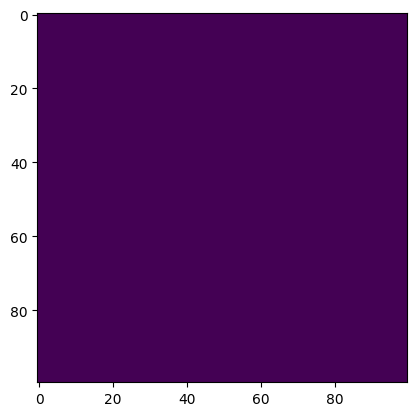

In [ ]:
plt.imshow(S.p3)

In [ ]:
S.stack()[2]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
# poblacion
P = [0.6, 0.3, 0.1]
p1, p2, p3 = P
bj1, al1 = sum(P[:0]), sum(P[:1])
bj2, al2 = sum(P[:1]), sum(P[:2])
bj3, al3 = sum(P[:2]), sum(P[:3])

print(f"Primero [{bj1},{al1}] - Segundo [{bj2},{al2}] - Tercero [{bj3:.3},{al3}] Suma {bj1+bj2+ bj3}")

Primero [0,0.6] - Segundo [0.6,0.8999999999999999] - Tercero [0.9,1.0] Suma 1.5


In [ ]:
Q = np.arange(1,10).reshape(3,3)
np.roll(np.roll(Q,1,axis=1),1,axis=0)

array([[9, 7, 8],
       [3, 1, 2],
       [6, 4, 5]])

In [ ]:
rng = np.random.default_rng()
rng.integers(4)

np.int64(2)

Pseudoalgoritmo de lo que necesito

    e = Espacio(n,m)
        # se inicializan M y V
        # donde V es el entorno de agentes
        #
        __e.inicializa_distribucion()
    e

In [ ]:
import numpy as np

def generar_matriz(t,
                   padding=2,
                   distribucion='gaussian',
                   **kwargs):
    """
    Genera una matriz nxn con valores positivos en la región interior
    y un borde de ancho 'padding' con ceros.

    Parameters
    ----------
    n : int
        Tamaño de la matriz.
    padding : int
        Número de filas/columnas de borde con valor cero.
    distribucion : str
        'gaussian', 'power_law' o 'binomial'.

    Parámetros adicionales (**kwargs)
    ---------------------------------
    Gaussian:
        mu=1.0
        sigma=0.2

    Power law:
        alpha=2.5

    Binomial:
        n_bin=10
        p=0.5

    Returns
    -------
    V : ndarray (n,n)
    """
    n, m = t
    if 2 * padding >= n:
        raise ValueError("padding demasiado grande para el tamaño de la matriz")

    V = np.zeros((n, n))

    interior_shape = (n - 2 * padding,
                      n - 2 * padding)

    if distribucion == 'gaussian':
        mu = kwargs.get('mu', 1.0)
        sigma = kwargs.get('sigma', 0.2)

        datos = np.random.normal(mu, sigma, interior_shape)

        # Garantizar positividad
        datos = np.abs(datos)

    elif distribucion == 'power_law':
        alpha = kwargs.get('alpha', 2.5)

        # Pareto desplazada para evitar ceros
        datos = np.random.pareto(alpha, interior_shape) + 1

    elif distribucion == 'binomial':
        n_bin = kwargs.get('n_bin', 10)
        p = kwargs.get('p', 0.5)

        datos = np.random.binomial(n_bin, p, interior_shape)

    else:
        raise ValueError(
            "distribucion debe ser 'gaussian', 'power_law' o 'binomial'"
        )

    V[padding:n-padding,
      padding:n-padding] = datos

    return V

In [ ]:
V = generar_matriz(
    (20,20),
    n=20,
    padding=2,
    distribucion='gaussian',
    mu=1.0,
    sigma=0.2
)

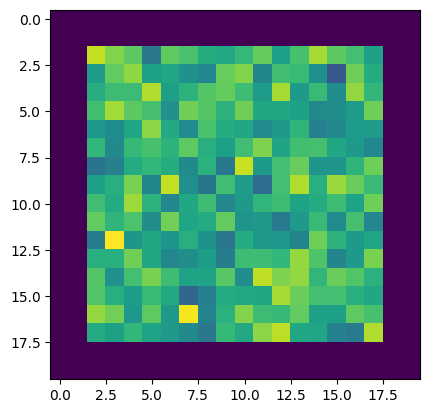

In [ ]:
plt.imshow(V)

In [ ]:
rng=random.default_rng()
u = rng.uniform(0, 1, size=(10,10))
datos = powerlaw.ppf(u, a=2)

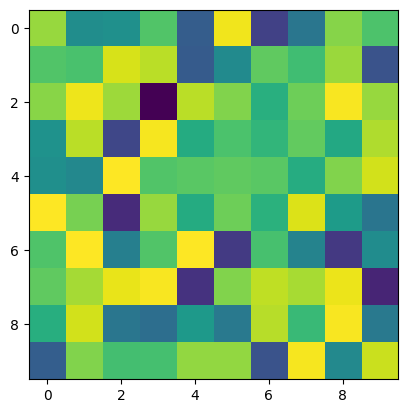

In [ ]:
plt.imshow(datos)

In [ ]:
n = 200
pad = 2
shp  = (n - 2 * pad,
        n - 2 * pad)
shp

(196, 196)

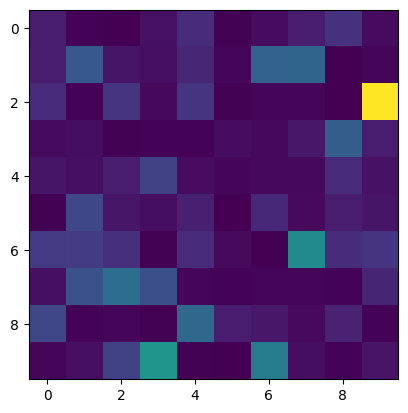

In [ ]:
plt.imshow(rng.pareto(2, size=(10,10)) + 1)